In [1]:
# testes estátisticos e os algoritmos
# tudo para fazer a validação cruzada

import pickle

import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import f_oneway, shapiro
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.multicomp import MultiComparison


# Avaliação dos algoritmos

## Tuning dos parâmetros com GridSearch

### Preparação dos dados

Comece recarregando as variáveis `X` e `y`, dos splits `train` e `test`, a partir do arquivo salvo `cover_type.pkl`.

In [5]:
import os
with open(os.path.join("cover_type.pkl"), "rb") as f:
    (X_train, y_train, X_test, y_test) = pickle.load(f)

Inspecione o `shape` desses objetos.

In [8]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7500, 53), (7500,), (2500, 53), (2500,))

Junte as variáveis preditoras em uma única variável `X`, e inspecione seu `shape`.

In [11]:
X = np.concatenate((X_train, X_test), axis=0)
X.shape

(10000, 53)

Junte a variável alvo em uma única variável `y`, e inspecione seu `shape`.

In [14]:
y = np.concatenate((y_train, y_test), axis=0)
y.shape

(10000,)

## Validação cruzada

Agora repita o exemplo da validação cruzada, usando o mesmo método e os mesmos parâmetros utilizados anteriormente. Entretanto, para limitar o tempo de execução, estou deixando comentados os algoritmos DecisionTree e SVM, e repetindo por apenas 10 loops. Podemos aumentar o loop depois.

10 rodadas para cada um dos algoritmos.

In [20]:
# decision_tree_results = []
random_forest_results = []
knn_results = []
logistic_results = []
# svm_results = []
neural_net_results = []

for i in range(10):
    print(f">>>>> LOOP {i} <<<<<\n")
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    # tree = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=1, min_samples_split=5, splitter='best')
    # scores = cross_val_score(tree, X, y, cv = kfold)
    # decision_tree_results.append(scores.mean())

    random_forest = RandomForestClassifier(criterion = 'entropy', min_samples_leaf = 1, min_samples_split=5, n_estimators = 10)
    scores = cross_val_score(random_forest, X, y, cv = kfold)
    random_forest_results.append(scores.mean())

    knn = KNeighborsClassifier()
    scores = cross_val_score(knn, X, y, cv = kfold)
    knn_results.append(scores.mean())

    lr = LogisticRegression(C = 1.0, solver = 'lbfgs', tol = 0.0001)
    scores = cross_val_score(lr, X, y, cv = kfold)
    logistic_results.append(scores.mean())

    # svm = SVC(kernel = 'rbf', C = 2.0)
    # scores = cross_val_score(svm, X, y, cv = kfold)
    # svm_results.append(scores.mean())

    neural_net = MLPClassifier(activation = 'relu', batch_size = 56, solver = 'adam')
    scores = cross_val_score(neural_net, X, y, cv = kfold)
    neural_net_results.append(scores.mean())

>>>>> LOOP 0 <<<<<



/home/fabiene/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fabiene/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

>>>>> LOOP 1 <<<<<



/home/fabiene/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fabiene/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

>>>>> LOOP 2 <<<<<



...

/home/fabiene/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fabiene/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

>>>>> LOOP 8 <<<<<



/home/fabiene/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fabiene/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

>>>>> LOOP 9 <<<<<



/home/fabiene/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/fabiene/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

# Consolide os resultados em um DataFrame, com o nome do método sendo o rótulo das colunas.

In [22]:
results = pd.DataFrame({
    # 'Decision tree': decision_tree_results,
    'Random forest': random_forest_results,
    'KNN': knn_results,
    'Logistic': logistic_results,
    # 'SVM': svm_results,
    'Neural net': neural_net_results
    })
results

,Random forest,KNN,Logistic,Neural net
0,0.7812,0.7546,0.7230,0.7853
1,0.7896,0.7522,0.7234,0.7842
2,0.7849,0.7588,0.7236,0.7821
3,0.7864,0.7531,0.7249,0.7799
4,0.7835,0.7556,0.7219,0.7820
5,0.7883,0.7581,0.7213,0.7824
6,0.7872,0.7561,0.7238,0.7850
7,0.7889,0.7582,0.7236,0.7853
8,0.7852,0.7547,0.7208,0.7863
9,0.7884,0.7549,0.7217,0.7886


In [24]:
# Mean =>random forest é o que tem o melhor resultado, nde há a maior média.

# Exiba as estatísticas básicas para cada método no DataFrame.

In [26]:
results.describe()

,Random forest,KNN,Logistic,Neural net
count,10.000000,10.000000,10.000000,10.000000
mean,0.786360,0.755630,0.722800,0.784110
std,0.002664,0.002201,0.001306,0.002533
min,0.781200,0.752200,0.720800,0.779900
25%,0.784975,0.754625,0.721750,0.782175
50%,0.786800,0.755250,0.723200,0.784600
75%,0.788375,0.757600,0.723600,0.785300
max,0.789600,0.758800,0.724900,0.788600


## Exiba a variância de cada método.

# *  quanto maior a variância mais diferente é os resultados dos algoritmos, o algoritmo não é equivalente. 

# * Melhor modelo é com a menor variância. 



In [28]:
results.var()

Random forest    0.000007
KNN              0.000005
Logistic         0.000002
Neural net       0.000006
dtype: float64

## Exiba o desvio padrão dividido pela média de cada método, como um valor percentual.

In [30]:
(results.std() / results.mean()) * 100

Random forest    0.338755
KNN              0.291285
Logistic         0.180741
Neural net       0.322997
dtype: float64

In [31]:
# 5:40

## Teste de normalidade

Use o método de Shapiro para determinar se os resultados podem ser considerados amostras de uma distribuição normal.

In [33]:
# shapiro(decision_tree_results)
print('random_forest_results: ',shapiro(random_forest_results))
print('knn_results',shapiro(knn_results))
print('logistic_results', shapiro(logistic_results))
# shapiro(svm_results)
print('neural_net_results',shapiro(neural_net_results))


random_forest_results:  ShapiroResult(statistic=0.9425598957476045, pvalue=0.5818337928165901)
knn_results ShapiroResult(statistic=0.9436763112020883, pvalue=0.5945967687046025)
logistic_results ShapiroResult(statistic=0.9434212490226853, pvalue=0.5916713598871064)
neural_net_results ShapiroResult(statistic=0.9691826988326744, pvalue=0.883165608311972)


### statistic mais próximo de 1, mais os dados se assemelham a uma distribuição normal. 

os valores foram acima dos 0,94.


## p_value, se o valor for maior ou igual ao 0,05, NÃO há evidências para rejeitar a hipótese nula. Ou seja, os dados podem ser considerados normalmente distribuídos, considerando todos esses algoritmos. 


Exiba um gráfico dos resultados utilizando a função `sns.displot`.

In [46]:
# sns.displot(decision_tree_results, kind = 'kde');

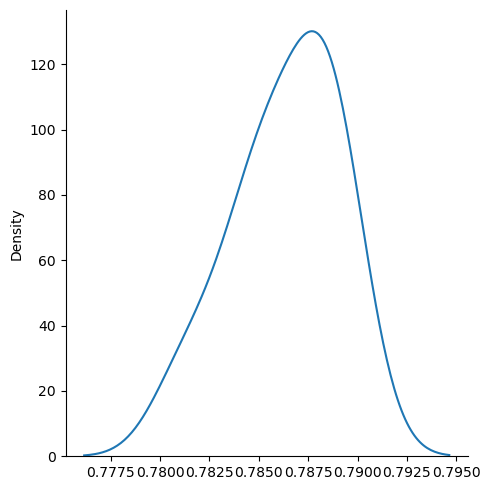

In [48]:
sns.displot(random_forest_results, kind = 'kde');

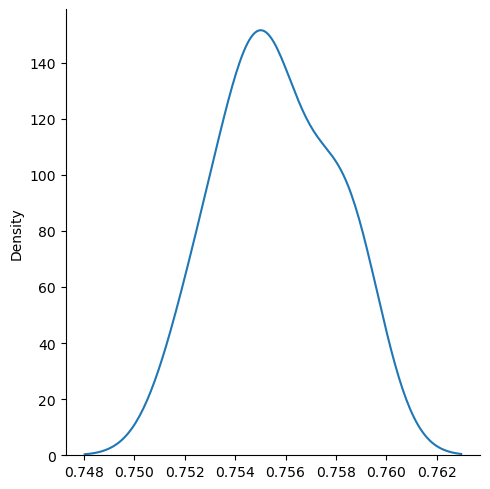

In [50]:
sns.displot(knn_results, kind = 'kde');

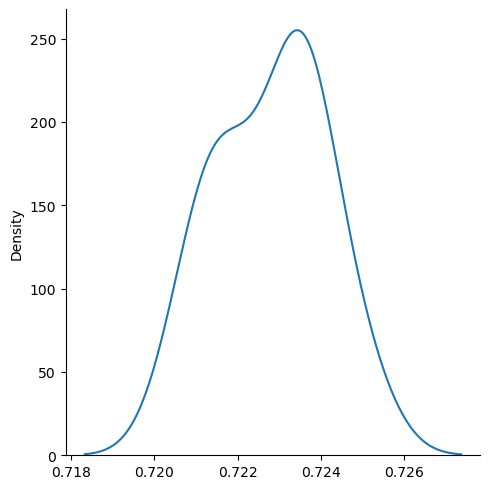

In [52]:
sns.displot(logistic_results, kind = 'kde');

In [54]:
# sns.displot(svm_results, kind = 'kde');

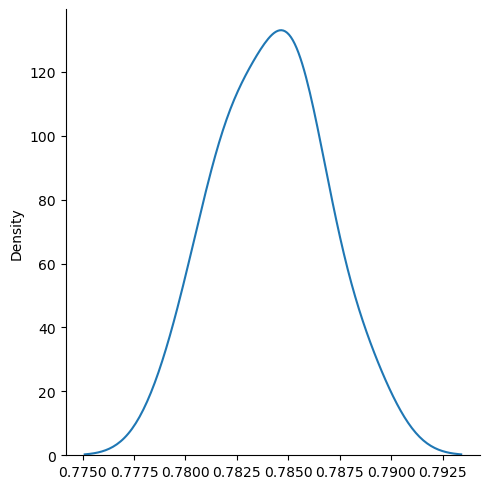

In [56]:
sns.displot(neural_net_results, kind = 'kde');


no gráfico de fato os dados seguem uma distribuição normal.


## Teste de hipótese com ANOVA e Tukey

Utilize o método ANOVA (one way) para determinar se os resultados são estatisticamente iguais ou se existe pelo menos um resultado diferente.

In [61]:
_, p = f_oneway(
    # decision_tree_results,
    random_forest_results,
    knn_results,
    logistic_results,
    # svm_results,
    neural_net_results
    )
p

4.0538960177439065e-39

### valor extramente baixo do p, o que é bem menor do valor alpha (0,05). Rejeitamos a hipótese nula. Ou seja, existe diferença estatisticamete significativa entre o desempenho ou as médias de pelo menos 2 dos algoritmos testados. 


In [68]:
results.describe() # random forest e neural parecidos, há mais diferenças estatísticas no knn e logistic, olhando mean

,Random forest,KNN,Logistic,Neural net
count,10.000000,10.000000,10.000000,10.000000
mean,0.786360,0.755630,0.722800,0.784110
std,0.002664,0.002201,0.001306,0.002533
min,0.781200,0.752200,0.720800,0.779900
25%,0.784975,0.754625,0.721750,0.782175
50%,0.786800,0.755250,0.723200,0.784600
75%,0.788375,0.757600,0.723600,0.785300
max,0.789600,0.758800,0.724900,0.788600


In [70]:
_, p2 = f_oneway(
    random_forest_results,
    neural_net_results
    )
p2 # curiosidade, e verificamos que o p2 > que o alpha, o que não rejeita a hipótese nula, e não há diferença estatisticamente.

0.06876477596000206

Considerando $alpha = 0.05$, qual a conclusão do teste?

In [73]:
results

,Random forest,KNN,Logistic,Neural net
0,0.7812,0.7546,0.7230,0.7853
1,0.7896,0.7522,0.7234,0.7842
2,0.7849,0.7588,0.7236,0.7821
3,0.7864,0.7531,0.7249,0.7799
4,0.7835,0.7556,0.7219,0.7820
5,0.7883,0.7581,0.7213,0.7824
6,0.7872,0.7561,0.7238,0.7850
7,0.7889,0.7582,0.7236,0.7853
8,0.7852,0.7547,0.7208,0.7863
9,0.7884,0.7549,0.7217,0.7886


## Agora vamos utilizar o método `melt` do Pandas para reorganizar o dataframe de resultados.

In [76]:
results_df = results.melt(var_name='algorithm', value_name='accuracy')
results_df

,algorithm,accuracy
0,Random forest,0.7812
1,Random forest,0.7896
2,Random forest,0.7849
3,Random forest,0.7864
4,Random forest,0.7835
5,Random forest,0.7883
6,Random forest,0.7872
7,Random forest,0.7889
8,Random forest,0.7852
9,Random forest,0.7884


Utilize a classe `MultiComparison` para criar uma instância que será utilizada como base para comparar os algoritmos e seus resultados.

In [79]:
compare_algorithms = MultiComparison(results_df['accuracy'], results_df['algorithm'])

Utilize essa instância para determinar os resultados do teste de Tukey. Exiba os resultados.

In [82]:
statistical_test = compare_algorithms.tukeyhsd()
print(statistical_test)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1       group2    meandiff p-adj   lower   upper  reject
---------------------------------------------------------------
       KNN      Logistic  -0.0328    0.0 -0.0355 -0.0301   True
       KNN    Neural net   0.0285    0.0  0.0258  0.0312   True
       KNN Random forest   0.0307    0.0   0.028  0.0334   True
  Logistic    Neural net   0.0613    0.0  0.0586   0.064   True
  Logistic Random forest   0.0636    0.0  0.0609  0.0663   True
Neural net Random forest   0.0022 0.1302 -0.0004  0.0049  False
---------------------------------------------------------------


médios, meandiff, pares de algoritmos, ver se as diferenças são estatisticamentes significativas. 

knn o pior desempenho, negativo. Os melhores o neural e random forest. 

meandiff é 0,0636, o random forest supera o logistic 

já o menor meandiff é de 0,0022, pelo Neural net  e Random forest,mostra que não há muita diferença entre os algoritmos. Ainda que a diferença seja pequena, porém significativa, já que o valor p-adj é de 0,1302.


O teste tukey confirmou que todos os algoritmos diferem significativamente entre si. Random Forest e neural sendo os  melhores. Depois regressão logísicas e por último knn.

Exiba a média dos resultados.

In [86]:
results.mean()

Random forest    0.78636
KNN              0.75563
Logistic         0.72280
Neural net       0.78411
dtype: float64

## Exiba os resultados do teste estatístico em um plot.

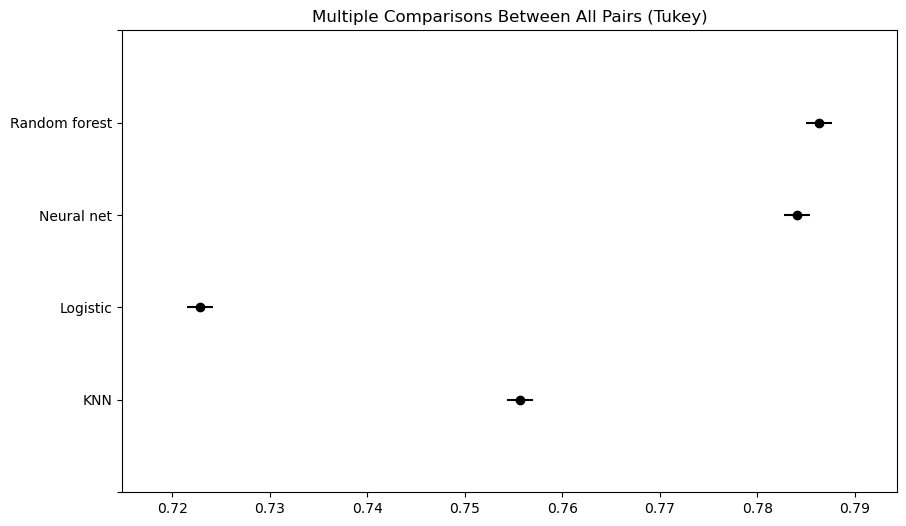

In [89]:
statistical_test.plot_simultaneous();

Quais conclusões são possíveis a partir desses resultados?

## Salvar um classificador treinado